# TODO
Temp intendency

In [1]:
import time
from datetime import date, datetime
import marineHeatWaves as mhw
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd
import warnings
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor

In [2]:
ssts=np.load(r'/lustre/home/yuhanxue/data/oisstv2r01_ssts.npy')
#t = np.arange(date(1981,9,1).toordinal(),date(2021,12,31).toordinal()+1)
#sst=ssts[:,:,t.shape[0]+1:]
times=np.load(r'/lustre/home/yuhanxue/data/oisstv2r01_times.npy',allow_pickle=True)
#time=times[t.shape[0]+1:]
t = np.arange(date(1981,9,1).toordinal(),date(2021,12,31).toordinal()+1)
ssts=ssts[:,:,:t.shape[0]]

In [3]:
file='/lustre/home/yuhanxue/data/oisst/V2.1/oisst-avhrr-v02r01.19810901.nc'
daset=nc.Dataset(file)
lat_4=np.array(daset.variables['lat'])
lon_4=np.array(daset.variables['lon'])
lat_target=(lat_4>35)&(lat_4<50)
lon_target=(lon_4>195)&(lon_4<230)
sst=ssts[lat_target,:,:][:,lon_target,:]

In [4]:
sst_d=sst[:,:,1:]-sst[:,:,:-1]

In [21]:
demo=np.average(np.average(sst_d,axis=0),axis=0)

In [25]:
t2 = np.arange(date(1981,9,2).toordinal(),date(2021,12,31).toordinal()+1)
mhws, clim = mhw.detect(t2,demo,climatologyPeriod=[1993,2020])
cg=clim['seas']

In [23]:
clim.keys()

dict_keys(['thresh', 'seas', 'missing'])

(-0.5, 0.5)

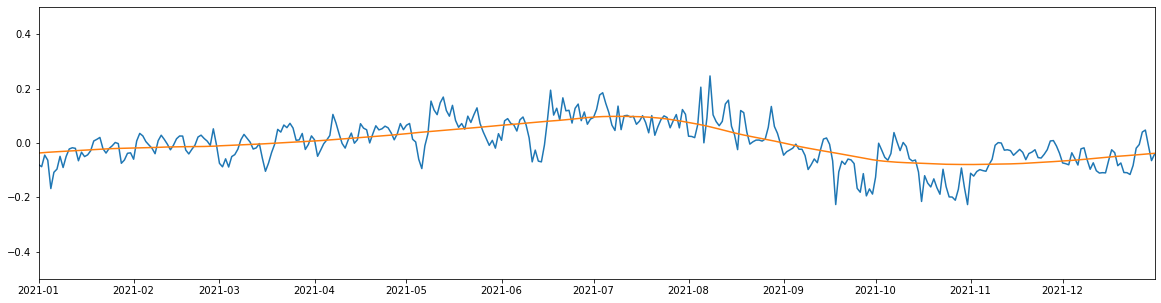

In [30]:
plt.figure(figsize=[20,5])
t2_p=pd.date_range('1981-09-02','2021-12-31',freq='1D')
plt.plot(t2_p,demo)
plt.plot(t2_p,cg)
plt.xlim(t2_p[-365],t2_p[-1])
plt.ylim(-0.5,0.5)

In [ ]:
np.save(demo,'')

In [37]:
[(demo-cg)>0.05][0].shape[0]

14731

In [50]:
index=(demo-cg)>0.05
index.shape[0]+1

14732

In [51]:
np.zeros(shape=[index.shape[0]+1]).shape

(14732,)

In [54]:
index2==1

array([False,  True, False, ..., False, False, False])

(-0.5, 0.5)

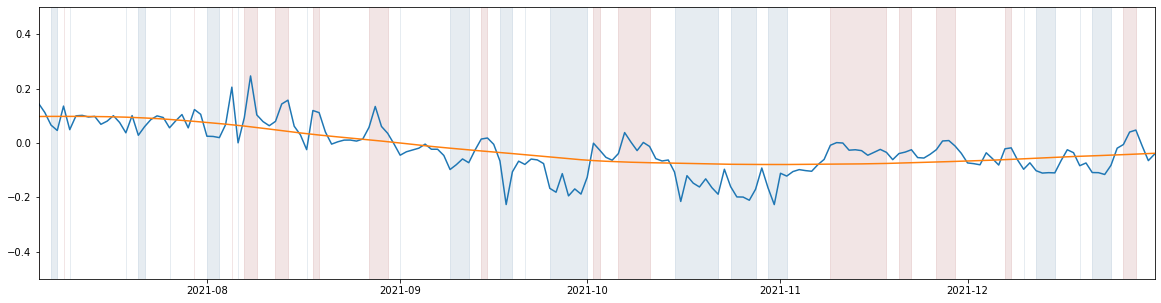

In [67]:
plt.figure(figsize=[20,5])
t2_p=pd.date_range('1981-09-02','2021-12-31',freq='1D')
index=(demo-cg)>0.05
y0=np.zeros(shape=[index.shape[0]])
y1=np.copy(y0)
y1[:]=1
y0[:]=-1
plt.plot(t2_p,demo)
plt.plot(t2_p,cg)
plt.fill_between(t2_p,y0,y1,where=demo-cg>0.03,alpha=0.1,color='#840000')
plt.fill_between(t2_p,y0,y1,where=demo-cg<-0.03,alpha=0.1,color='#10457e')
plt.xlim(t2_p[-180],t2_p[-1])
plt.ylim(-0.5,0.5)

In [ ]:
start=[]
end=[]
for i in range([(demo-cg)>0.05][0].shape[0]):
    if [(demo-cg)>0.05][0][i]:
        start.append(t2_p[i])
        